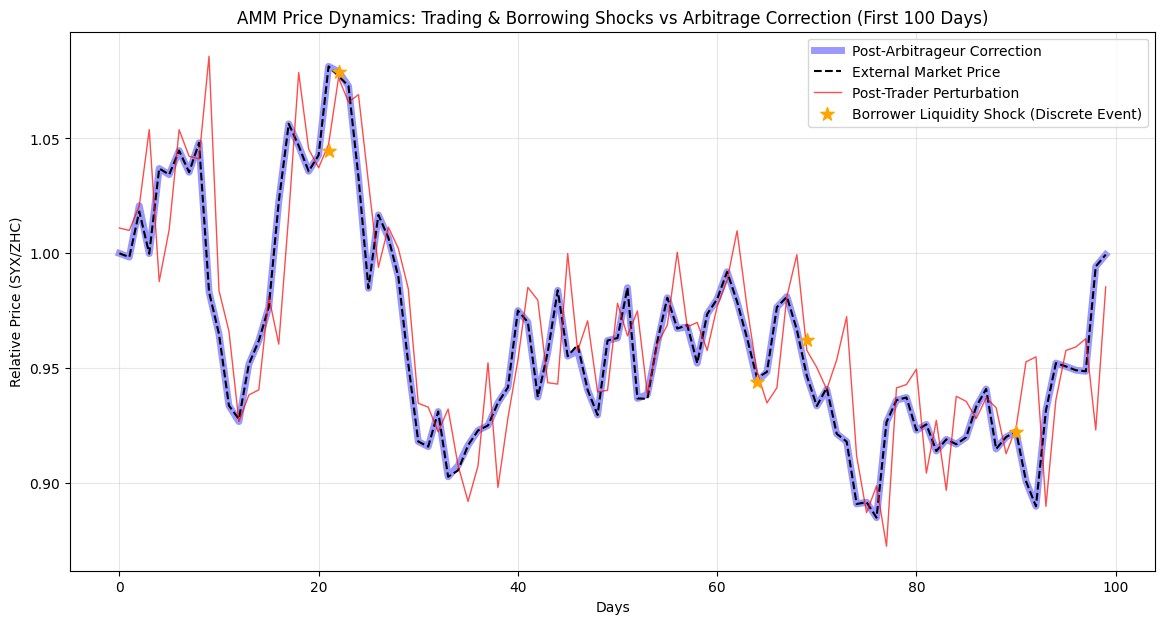

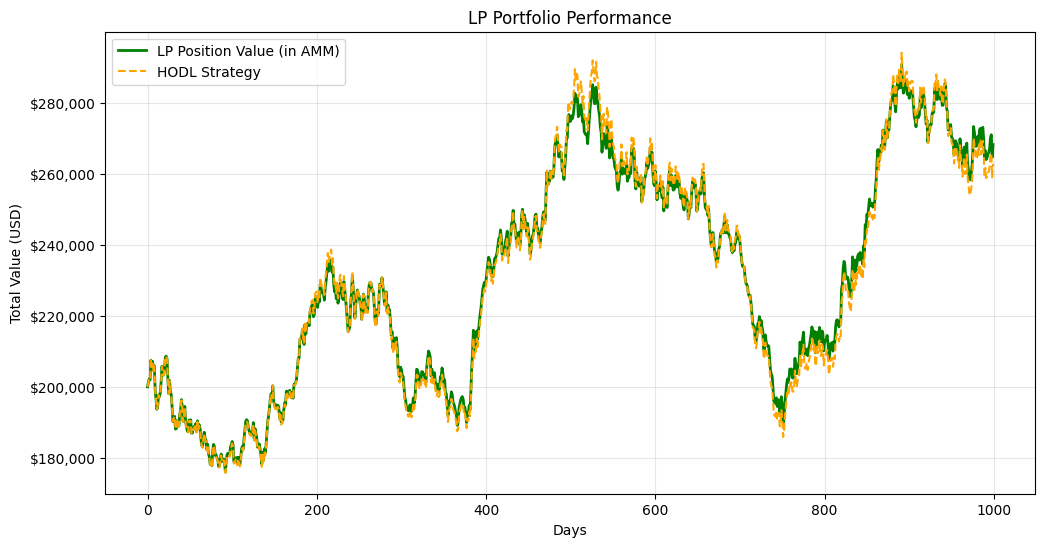

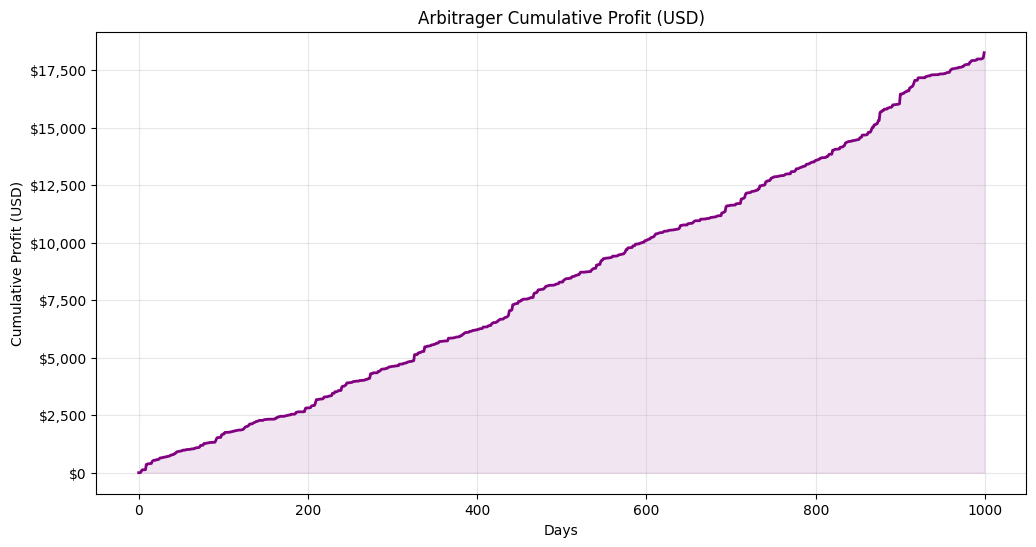

LP Unrealized P&L (USD): $68,224.77
LP Impermanent Loss (USD): $5,438.10
Protocol Accumulated Fees (USD): $1,533.07
Arbitrager Total Profit (USD): $18,249.76


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from market import Market
from contract import AMMContract
from plot import *
from market_entities import *
np.random.seed(123)
def run_simulation():
    days = 1000
    initial_syx = 100000.0
    initial_zhc = 100000.0
    
    market = Market(initial_px=1.0, initial_py=1.0, mu_x=0.05, mu_y=0.03, 
                    sigma_x=0.4, sigma_y=0.1, rho=0.3, days=days)
    contract = AMMContract(x_init=initial_syx, y_init=initial_zhc)
    lp = LP(initial_syx, initial_zhc)
    trader = Trader()
    arbitrager = Arbitrager()
    borrower = Borrower()
    
    records = []
    cumulative_arb_profit_usd = 0.0

    for day in range(days):
        current_market_price = market.get_price(day)
        abs_px, abs_py = market.get_absolute_prices(day)
        
        price_pre_trade = contract.get_internal_price()
        
        trader.random_trade(contract)
        price_post_trade = contract.get_internal_price()
        
        borrower.random_action(contract, day)
        price_post_borrow = contract.get_internal_price()
        
        prev_arb_zhc = arbitrager.cumulative_profit_zhc
        arbitrager.execute_arbitrage(contract, current_market_price)
        daily_arb_profit_zhc = arbitrager.cumulative_profit_zhc - prev_arb_zhc
        
        daily_arb_profit_usd = daily_arb_profit_zhc * abs_py
        cumulative_arb_profit_usd += daily_arb_profit_usd
        
        protocol_fee_usd = (contract.protocol_fee_x * abs_px) + (contract.protocol_fee_y * abs_py)
    
        current_lp_value_usd = (contract.x * abs_px) + ((contract.y + contract.debt_y) * abs_py)
        hodl_value_usd = (initial_syx * abs_px) + (initial_zhc * abs_py)
        
        records.append({
            'Day': day,
            'Market_Price_SYX_USD': abs_px,
            'Market_Price_ZHC_USD': abs_py,
            'Market_Relative_Price': current_market_price,
            'AMM_Price_Pre': price_pre_trade,
            'AMM_Price_Post_Trader': price_post_trade,
            'AMM_Price_Post_Borrow': price_post_borrow,
            'AMM_Price_Post_Arb': contract.get_internal_price(),
            'Pool_SYX': contract.x,
            'Pool_ZHC': contract.y,
            'Pool_Debt_ZHC': contract.debt_y,
            'Protocol_Fee_USD': protocol_fee_usd,
            'Arbitrageur_Profit_USD': cumulative_arb_profit_usd,
            'LP_Position_USD': current_lp_value_usd,
            'LP_HODL_Value_USD': hodl_value_usd
        })
        
    borrower.force_repay_all(contract, days - 1)
        
    df = pd.DataFrame(records)
    
    final_px, final_py = market.get_absolute_prices(days - 1)
    lp_unrealized_pnl_usd, lp_impermanent_loss_usd = lp.calculate_pnl(contract, final_px, final_py)
    
    return df, lp_unrealized_pnl_usd, lp_impermanent_loss_usd



if __name__ == "__main__":
    df_results, lp_pnl_usd, lp_il_usd = run_simulation()

    plot_price_dynamics(df_results) 
    plot_lp_performance(df_results)
    plot_arbitrager_profit_curve(df_results)

    print(f"LP Unrealized P&L (USD): ${lp_pnl_usd:,.2f}")
    print(f"LP Impermanent Loss (USD): ${lp_il_usd:,.2f}")
    print(f"Protocol Accumulated Fees (USD): ${df_results['Protocol_Fee_USD'].iloc[-1]:,.2f}")
    print(f"Arbitrager Total Profit (USD): ${df_results['Arbitrageur_Profit_USD'].iloc[-1]:,.2f}")